In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

df = pd.read_csv(r"C:\Users\Prashastini N\Desktop\nassau-candy-profitability-analysis\data\cleaned_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Time
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,851
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,646
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,646
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,646
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-05-07,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,736


In [2]:
# Creating KPIs

df["Gross Margin %"] = (df["Gross Profit"] / df["Sales"]) * 100

df["Profit per Unit"] = df["Gross Profit"] / df["Units"]

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Time,Gross Margin %,Profit per Unit
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,851,64.923077,2.11
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,646,65.333333,2.45
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,646,71.346705,2.49
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,646,69.444444,2.50
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-05-07,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,736,65.333333,2.45


In [3]:
# Product Level Profitability Table

product_profit = df.groupby("Product Name").agg({
    "Sales":"sum",
    "Gross Profit":"sum",
    "Units":"sum"
}).sort_values(by="Gross Profit", ascending=False)

product_profit

,Sales,Gross Profit,Units
Product Name,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596
Wonka Bar - Milk Chocolate,26867.75,17443.37,8267
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755
Wonka Bar - Fudge Mallows,24890.40,16593.60,6914
Lickable Wallpaper,7860.00,3930.00,393
Wonka Gum,597.50,310.70,478
Everlasting Gobstopper,130.00,104.00,13
Kazookles,1205.75,92.75,371


In [4]:
product_profit["Gross Margin %"] = (product_profit["Gross Profit"] / product_profit["Sales"]) * 100
product_profit["Profit per Unit"] = product_profit["Gross Profit"] / product_profit["Units"]

product_profit

,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit
Product Name,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45
Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49
Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40
Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00
Wonka Gum,597.50,310.70,478,52.000000,0.65
Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00
Kazookles,1205.75,92.75,371,7.692308,0.25


In [5]:
# Revenue Contribution

total_sales = product_profit["Sales"].sum()

product_profit["Revenue Contribution %"] = (product_profit["Sales"] / total_sales) * 100

product_profit

,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Revenue Contribution %
Product Name,,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,19.660098
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,20.090472
Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,18.949825
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,16.627413
Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,17.555200
Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00,5.543658
Wonka Gum,597.50,310.70,478,52.000000,0.65,0.421417
Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00,0.091689
Kazookles,1205.75,92.75,371,7.692308,0.25,0.850416


 The top five Wonka chocolate bars contribute the majority of total revenue, each accounting for roughly 16–20% of sales, indicating strong product concentration around flagship items.  
Most chocolate products maintain healthy margins (~65–71%), while products like Kazookles show extremely low margins (~7.7%), suggesting potential pricing or cost inefficiencies.

In [6]:
# Profit Contribution

total_profit = product_profit["Gross Profit"].sum()

product_profit["Profit Contribution %"] = (product_profit["Gross Profit"] / total_profit) * 100

product_profit

,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Revenue Contribution %,Profit Contribution %
Product Name,,,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,19.660098,20.715882
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,20.090472,19.916141
Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,18.949825,18.667431
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,16.627413,18.000263
Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,17.555200,17.758030
Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00,5.543658,4.205782
Wonka Gum,597.50,310.70,478,52.000000,0.65,0.421417,0.332503
Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00,0.091689,0.111298
Kazookles,1205.75,92.75,371,7.692308,0.25,0.850416,0.099259


Profit generation is highly concentrated among the top five Wonka chocolate bars, which together contribute the overwhelming majority of total profit.  
Although some niche products have high margins, their extremely low sales volumes result in minimal overall profit contribution.

In [7]:
# High Margin Products

product_profit.sort_values(by="Gross Margin %", ascending=False)

,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Revenue Contribution %,Profit Contribution %
Product Name,,,,,,,
Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00,0.091689,0.111298
Hair Toffee,76.50,59.50,17,77.777778,3.50,0.053955,0.063675
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,16.627413,18.000263
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,19.660098,20.715882
Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,17.555200,17.758030
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,20.090472,19.916141
Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,18.949825,18.667431
Laffy Taffy,53.73,33.48,27,62.311558,1.24,0.037896,0.035829
Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25,0.055542,0.050566


Several products such as Everlasting Gobstopper and Hair Toffee show very high margins, but their overall revenue contribution is extremely small due to low sales volume.  
In contrast, Wonka chocolate bars combine both strong margins and high sales, making them the most financially valuable products in the portfolio.

In [8]:
# High Sales but Low Margin Products

product_profit.sort_values(by="Sales", ascending=False)

,Sales,Gross Profit,Units,Gross Margin %,Profit per Unit,Revenue Contribution %,Profit Contribution %
Product Name,,,,,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,20.090472,19.916141
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,19.660098,20.715882
Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,18.949825,18.667431
Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,17.555200,17.758030
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,16.627413,18.000263
Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00,5.543658,4.205782
Kazookles,1205.75,92.75,371,7.692308,0.25,0.850416,0.099259
Wonka Gum,597.50,310.70,478,52.000000,0.65,0.421417,0.332503
Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00,0.091689,0.111298


The highest sales volumes are driven by the Wonka chocolate bar products, which also generate the majority of overall revenue and profit.  
However, products like Kazookles show relatively low margins despite moderate sales, indicating potential pricing or cost structure inefficiencies.

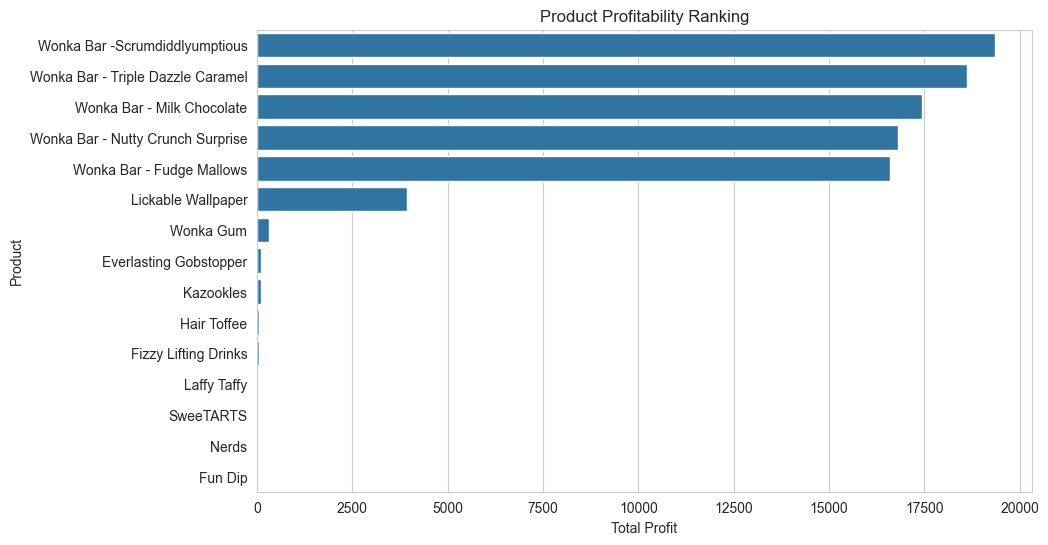

In [9]:
# Profitability Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    x=product_profit["Gross Profit"],
    y=product_profit.index
)

plt.title("Product Profitability Ranking")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.show()

The analysis shows that Wonka chocolate bars dominate overall profitability, with Scrumdiddlyumptious and Triple Dazzle Caramel generating the highest total profit. 
Most non-chocolate products contribute very little to overall profits. 
This suggests the company’s profit is highly concentrated in a few high-performing chocolate products.

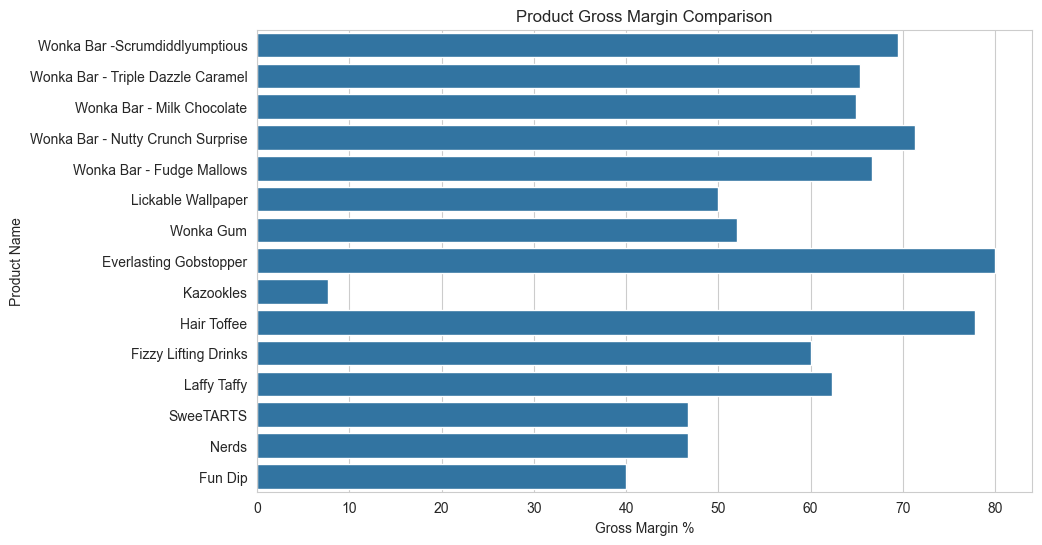

In [10]:
# Margin Comparison

plt.figure(figsize=(10,6))

sns.barplot(
    x=product_profit["Gross Margin %"],
    y=product_profit.index
)

plt.title("Product Gross Margin Comparison")

plt.show()

Gross margin varies significantly across products. 
Items like Everlasting Gobstopper and Hair Toffee have very high margins, indicating strong pricing power or low production costs. 
However, high-margin products do not always translate into high total profit due to lower sales volume.

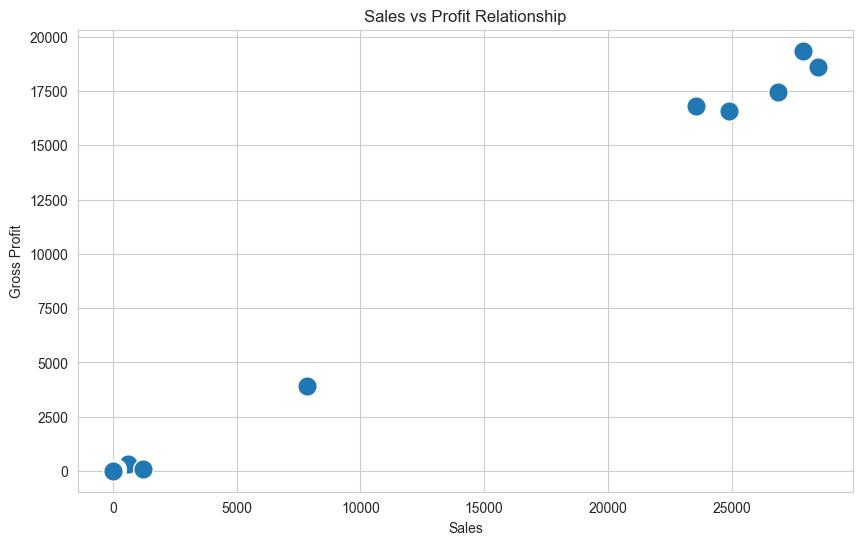

In [11]:
# Sales vs Profit Scatter

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Sales",
    y="Gross Profit",
    data=product_profit,
    s=200
)

plt.title("Sales vs Profit Relationship")

plt.show()

There is a strong positive relationship between sales and profit, indicating that higher-selling products generally generate more profit. 
The chocolate bar products cluster in the high-sales, high-profit region. 
Low-selling products remain near the origin, showing minimal contribution to overall profitability.

In [12]:
product_profit.to_csv(r"C:\Users\Prashastini N\Desktop\nassau-candy-profitability-analysis\data\product_profitability.csv")